<a href="https://colab.research.google.com/github/AyaAbdElNaem/Deep_Learning/blob/main/Deep_Sec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Single layer logistic regression

In [ ]:
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-q466duxn
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-q466duxn
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done


In [ ]:
# general libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling

# ignore warnings
import warnings
warnings.simplefilter('ignore')

In [ ]:
!git clone https://github.com/toelt-llc/ADL-Book-2nd-Ed.git

Cloning into 'ADL-Book-2nd-Ed'...
remote: Enumerating objects: 2285, done.
remote: Counting objects: 100% (405/405), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 2285 (delta 192), reused 405 (delta 192), pack-reused 1880 (from 1)
Receiving objects: 100% (2285/2285), 752.95 MiB | 40.24 MiB/s, done.
Resolving deltas: 100% (1140/1140), done.


In [ ]:
# We also clone the repository containing the dataset.

!git clone https://github.com/Shenggan/BCCD_Dataset.git

Cloning into 'BCCD_Dataset'...
remote: Enumerating objects: 800, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 800 (delta 8), reused 6 (delta 6), pack-reused 789 (from 1)
Receiving objects: 100% (800/800), 7.39 MiB | 15.59 MiB/s, done.
Resolving deltas: 100% (379/379), done.


In [ ]:
import sys
sys.path.append('ADL-Book-2nd-Ed/modules/')

from read_bccd_dataset import read_data
from style_setting import set_style

In [ ]:
rd = read_data()
dataset = rd.preprocess_bccd_dataset()
dataset_reduced = dataset.loc[(dataset['cell_type'] == 'RBC') | (dataset['cell_type'] == 'WBC')]
bccd_features = dataset_reduced[['xmin', 'xmax', 'ymin', 'ymax']]
bccd_labels = dataset_reduced['cell_type']

In [ ]:
num_observations = len(bccd_features)
print('Number of total samples: ', num_observations)

Number of total samples:  4527


In [ ]:
bccd_features.head()

,xmin,xmax,ymin,ymax
0,184,287,105,227
1,75,186,85,204
2,291,407,195,333
3,500,609,313,417
4,269,366,54,155


In [ ]:
# The following line contains the path to fonts that are used to plot result in
# a uniform way.

f = set_style().set_general_style_parameters()

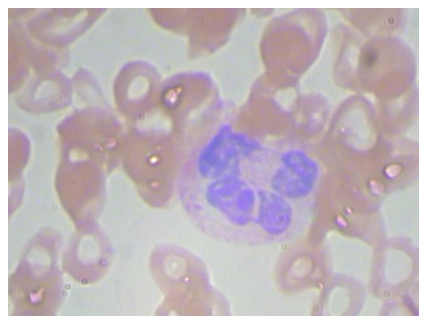

In [ ]:
# Image Example

fig = plt.figure()
ax = fig.add_subplot(111)
# add axes to the image
plt.axis('off')
# read and plot the image
image = plt.imread('BCCD_Dataset/BCCD/JPEGImages/BloodImage_00000.jpg')
plt.imshow(image)

In [ ]:
#Data Splitting
np.random.seed(42)
rnd = np.random.rand(len(bccd_features)) < 0.8

train_x = bccd_features[rnd] # training dataset (features)
train_y = bccd_labels[rnd] # training dataset (labels)
test_x = bccd_features[~rnd] # testing dataset (features)
test_y = bccd_labels[~rnd] # testing dataset (labels)

print('The training dataset dimensions are: ', train_x.shape)
print('The testing dataset dimensions are: ', test_x.shape)

The training dataset dimensions are:  (3631, 4)
The testing dataset dimensions are:  (896, 4)


In [ ]:
# The following lines are need to convert the labels from RBC/WBC notation to 0/1 notation.
# This is fundamental to correctly train the net.

train_y_bin = np.zeros(len(train_y))
train_y_bin[train_y == 'WBC'] = 1

test_y_bin = np.zeros(len(test_y))
test_y_bin[test_y == 'WBC'] = 1

In [ ]:
def build_model():

  # one unit as network's output
  # sigmoid function as activation function
  # sequential groups a linear stack of layers into a tf.keras.Model
  # activation parameter: if you don't specify anything, no activation
  # is applied (i.e. "linear" activation: a(x) = x).
  model = keras.Sequential([
    layers.Dense(1, input_shape = [len(train_x.columns)], activation = 'sigmoid')
  ])

  # optimizer that implements the RMSprop algorithm
  optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001)

  # the compile() method takes a metrics argument, which can be a list of metrics
  # loss = cross-entropy, metrics = accuracy,
  model.compile(loss = 'binary_crossentropy',
                optimizer = optimizer,
                metrics = ['binary_crossentropy','binary_accuracy'])

  return model

In [ ]:
model = build_model()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 500

history = model.fit(
  train_x, train_y_bin,
  epochs = EPOCHS, verbose = 0,
  callbacks = [tfdocs.modeling.EpochDots()])

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 1)

In [ ]:
#Convert history to Dataframe
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

NameError: name 'history' is not defined

In [ ]:
# The following line contains the path to fonts that are used to plot result in
# a uniform way.

f = set_style().set_general_style_parameters()

NameError: name 'hist' is not defined

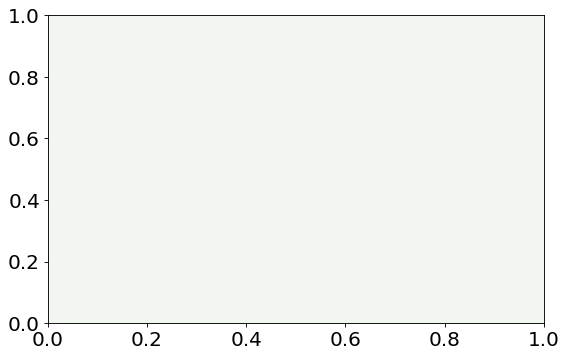

In [ ]:
# Cost Function vs. Number of Iterations PLOT

fig = plt.figure()
ax = fig.add_subplot(111)

plt.plot(hist['epoch'], hist['binary_crossentropy'], color = 'blue')

plt.ylabel('Cost Function (cross-entropy)', fontproperties = fm.FontProperties(fname = f))
plt.xlabel('Number of Iterations', fontproperties = fm.FontProperties(fname = f))

plt.ylim(-5, 20)
plt.xlim(0, 500)

plt.axis(True)
plt.show()

In [ ]:
test_predictions = model.predict(test_x).flatten() # predict cell type with the built logistic regression model

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
weights = model.get_weights() # return a numpy list of weights
print(weights)

In [ ]:
# The following lines compute the accuracy on the test set.

test_predictions1 = test_predictions > 0.5
tp = np.sum((test_predictions1 == 1) & (test_y_bin == 1))
tn = np.sum((test_predictions1 == 0) & (test_y_bin == 0))
accuracy_test = (tp + tn)/len(test_y)
print('The accuracy on the test set is equal to: ', int(accuracy_test*100), '%.')

The accuracy on the test set is equal to:  23 %.


###Single Layer Linear Regression

###The same as logistic with some **differences**

1/ model = keras.Sequential([
    layers.Dense(1, input_shape = [len(train_x.columns)])
  ]) NO Activation function

2/Metrics (mse)


###Multiclass_Classification


In [ ]:
def build_model(opt):
  # create model
	model = keras.Sequential()
	model.add(layers.Dense(15, input_dim = 784, activation = 'relu')) # add first hidden layer and set input dimensions
	model.add(layers.Dense(10, activation = 'softmax')) # add output layer
	# compile model
	model.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['categorical_accuracy'])
	return model

In [ ]:
model = build_model(tf.keras.optimizers.SGD(momentum = 0.0, learning_rate = 0.01))

In [ ]:
EPOCHS = 1000

history = model.fit(
  data_train_norm, labels_train,
  epochs = EPOCHS, verbose = 0,
  batch_size = data_train_norm.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

In [ ]:
test_loss, test_accuracy = model.evaluate(data_test_norm, labels_test, verbose = 0)
print('The accuracy on the test set is equal to: ', int(test_accuracy*100), '%.')

#stochastic

### the change in : Momentum & Batch_size

In [1]:
# the change in : Momentum & Batch_size
model_sgd = build_model(tf.keras.optimizers.SGD(momentum = 0.9, learning_rate = 0.0001))

NameError: name 'build_model' is not defined

In [ ]:
start = time.time()

EPOCHS = 100

history_sgd = model_sgd.fit(
  data_train_norm, labels_train,
  epochs = EPOCHS, verbose = 0,
  batch_size = 1,
  callbacks = [tfdocs.modeling.EpochDots()])

print('This took {:.2f} minutes.'.format((time.time() - start)/60))

#Mini-batch Gradient Descent

## the change in : Momentum & Batch_size

In [ ]:
start = time.time()

model_mbgd = build_model(tf.keras.optimizers.SGD(momentum = 0.9, learning_rate = 0.01))

EPOCHS = 100
history_mbgd = model_mbgd.fit(
  data_train_norm, labels_train,
  epochs = EPOCHS, verbose = 0,
  batch_size = 50,
  callbacks = [tfdocs.modeling.EpochDots()])

print('This took {:.2f} minutes.'.format((time.time() - start)/60))

In [ ]:

hist_mbgd = pd.DataFrame(history_mbgd.history)
hist_mbgd['epoch'] = history_mbgd.epoch
hist_mbgd.tail()

In [ ]:
#2nd way
def model_nlayers(num_neurons, num_layers):
    # build model
    inputs = keras.Input(shape = 784) # input layer
    # first hidden layer
    dense = layers.Dense(num_neurons, activation = 'relu')(inputs)
    # customized number of layers and neurons per layer
    for i in range(num_layers - 1):
        dense = layers.Dense(num_neurons, activation = 'relu')(dense)
    # output layer
    outputs = layers.Dense(10, activation = 'softmax')(dense)
    model = keras.Model(inputs = inputs, outputs = outputs, name = 'model')
    # set optimizer and loss
    opt = tf.keras.optimizers.SGD(momentum = 0.9, learning_rate = 0.0001)
    model.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['categorical_accuracy'])

    # train model
    history = model.fit(
      data_train_norm, labels_train,
      epochs = 200, verbose = 0,
      batch_size = 50,
      callbacks = [tfdocs.modeling.EpochDots()])
    # save performances
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    return hist, model

In [ ]:
res_10_1, model_10_1 = model_nlayers(10, 1)
res_10_2, model_10_2 = model_nlayers(10, 2)
res_10_3, model_10_3 = model_nlayers(10, 3)
res_10_4, model_10_4 = model_nlayers(10, 4)
res_100_4, model_100_4 = model_nlayers(100, 4)

In [ ]:
train_loss, train_accuracy = model_100_4.evaluate(data_train_norm, labels_train, verbose = 0)
print('The accuracy on the train set is equal to: ', int(train_accuracy*100), '%.')

test_loss, test_accuracy = model_100_4.evaluate(data_test_norm, labels_test, verbose = 0)
print('The accuracy on the test set is equal to: ', int(test_accuracy*100), '%.')

In [ ]:
#We now study how adding more neurons in a network with one hidden layer changes the training phase of the network itself.

res_1_1 = model_nlayers(1, 1)
res_5_1 = model_nlayers(5, 1)
res_15_1 = model_nlayers(15, 1)
res_30_1 = model_nlayers(30, 1)

##Comparison of Mini-batch Sizes

In [ ]:
def mini_batch_gradient_descent(mb_size):
  # build model
  model_mbgd = build_model(tf.keras.optimizers.SGD(momentum = 0.9, learning_rate = 0.0001))
  # set number of epochs
  EPOCHS = 100
  # train model
  history_mbgd = model_mbgd.fit(
    data_train_norm, labels_train,
    epochs = EPOCHS, verbose = 0,
    batch_size = mb_size,
    callbacks = [tfdocs.modeling.EpochDots()])
  # save performances
  hist_mbgd = pd.DataFrame(history_mbgd.history)
  hist_mbgd['epoch'] = history_mbgd.epoch
  return hist_mbgd

In [ ]:
start = time.time()
res_5 = mini_batch_gradient_descent(5)
time_5 = (time.time() - start)/60

start = time.time()
res_20 = mini_batch_gradient_descent(20)
time_20 = (time.time() - start)/60

start = time.time()
res_50 = mini_batch_gradient_descent(50)
time_50 = (time.time() - start)/60

start = time.time()
res_100 = mini_batch_gradient_descent(100)
time_100 = (time.time() - start)/60

start = time.time()
res_200 = mini_batch_gradient_descent(200)
time_200 = (time.time() - start)/60

start = time.time()
res_300 = mini_batch_gradient_descent(300)
time_300 = (time.time() - start)/60